In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('coding_challenge_dataset.csv')

In [3]:
data.head()

,client_id,age,income,loan_amount,loan_term,credit_score,employment_years,married,num_children,education_level,default
0,1,56,10767500,10685684,40,740,22,0,4,3,0
1,2,46,22976807,15321905,33,540,21,1,1,3,0
2,3,32,24277761,18958103,19,453,1,1,0,1,0
3,4,60,10291923,27973434,15,395,22,0,4,1,1
4,5,25,21931456,22217066,21,593,10,0,1,2,0


In [4]:
matrix = data.corr(numeric_only=True)
matrix

,client_id,age,income,loan_amount,loan_term,credit_score,employment_years,married,num_children,education_level,default
client_id,1.000000,-0.024857,-0.036880,0.027146,0.025545,-0.006350,-0.034860,-0.057590,0.054986,-0.045563,0.080620
age,-0.024857,1.000000,-0.056786,0.026762,0.025951,0.039742,0.030504,-0.014112,0.013194,0.001837,0.040146
income,-0.036880,-0.056786,1.000000,0.015411,-0.056437,-0.042353,0.003240,-0.030011,-0.010022,-0.022651,-0.616677
loan_amount,0.027146,0.026762,0.015411,1.000000,0.041659,0.060019,-0.009818,0.026430,-0.042497,0.004351,0.433778
loan_term,0.025545,0.025951,-0.056437,0.041659,1.000000,0.014753,-0.055969,0.023536,-0.009583,-0.028669,0.077168
credit_score,-0.006350,0.039742,-0.042353,0.060019,0.014753,1.000000,-0.003953,0.022338,0.001866,-0.006278,-0.067962
employment_years,-0.034860,0.030504,0.003240,-0.009818,-0.055969,-0.003953,1.000000,-0.016934,-0.018770,0.026496,-0.079351
married,-0.057590,-0.014112,-0.030011,0.026430,0.023536,0.022338,-0.016934,1.000000,0.010697,-0.001393,0.041910
num_children,0.054986,0.013194,-0.010022,-0.042497,-0.009583,0.001866,-0.018770,0.010697,1.000000,0.029536,-0.037380
education_level,-0.045563,0.001837,-0.022651,0.004351,-0.028669,-0.006278,0.026496,-0.001393,0.029536,1.000000,-0.020347


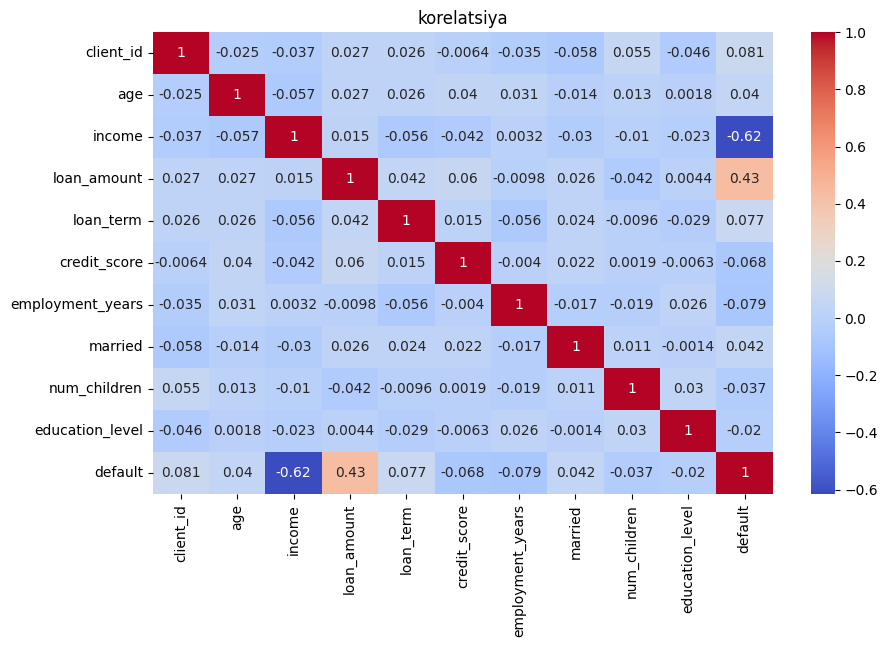

In [5]:
plt.figure(figsize=(10,6))
sns.heatmap(matrix,annot=True,cmap="coolwarm")
plt.title("korelatsiya")
plt.show()

In [6]:
feature_colums = [
    "age","income","loan_amount","loan_term","credit_score","employment_years",
    "married","num_children","education_level"
]

In [7]:
X = data[feature_colums]
Y = data["default"]

In [8]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [9]:
import lightgbm as lgb
from sklearn.metrics import roc_auc_score

In [10]:
lgb_model = lgb.LGBMClassifier(random_state=42)
lgb_model.fit(x_train,y_train)
lgb_pred = lgb_model.predict_proba(x_test)[:,-1]
lgb_aus = roc_auc_score(y_test,lgb_pred)
print("LightGBM  AUC: ", lgb_aus)

[LightGBM] [Info] Number of positive: 250, number of negative: 550
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000354 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 899
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.312500 -> initscore=-0.788457
[LightGBM] [Info] Start training from score -0.788457
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

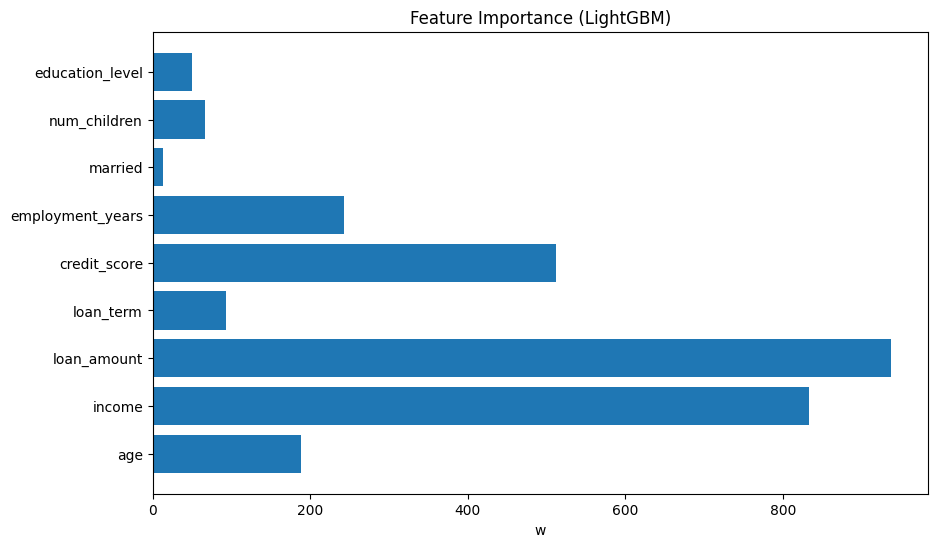

In [11]:
w = lgb_model.feature_importances_
s = x_train.columns


plt.figure(figsize=(10,6))
plt.barh(s,w)
plt.xlabel("w")
plt.title("Feature Importance (LightGBM)")
plt.show()

In [14]:
# Modellar va baholash uchun
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score


In [17]:
# XGBoost
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(x_train, y_train)
xgb_pred = xgb_model.predict_proba(x_test)[:,1]
xgb_auc = roc_auc_score(y_test, xgb_pred)
print("XGBoost AUC:", xgb_auc)


XGBoost AUC: 0.9970666666666667


c:\Users\behru\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:199: UserWarning: [10:49:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [18]:
# CatBoost
cat_model = CatBoostClassifier(verbose=0, random_state=42)
cat_model.fit(x_train, y_train)
cat_pred = cat_model.predict_proba(x_test)[:,1]
cat_auc = roc_auc_score(y_test, cat_pred)
print("CatBoost AUC:", cat_auc)


CatBoost AUC: 0.9969333333333333


In [20]:
# AUClarni solishtirish
auc_scores = {"LightGBM":lgb_aus, "XGBoost": xgb_auc, "CatBoost": cat_auc}
best_model_name = max(auc_scores, key=auc_scores.get)
print("Eng yaxshi model:", best_model_name, "with AUC =", auc_scores[best_model_name])


Eng yaxshi model: XGBoost with AUC = 0.9970666666666667
